# Isotropic 2PCF Benchmark: PyHermes vs pycorr vs TreeCorr

This notebook benchmarks isotropic two-point correlation measurements on the same Quijote halo catalogue.  The PyHermes warm run reads the current `examples/output` ConvolsData products, benchmark summaries are written under `examples/output`, and comparison figures are written under `examples/figs`. The goal is to compare wall-clock cost under a clear and reproducible setup, not to claim that one package universally replaces another.

Benchmark modes:

- **PyHermes warm**: reuse an existing `ConvolsData` field and compute the shell-window 2PCF.
- **PyHermes cold**: include the catalogue-to-field projection time if the `ConvolsData` file is missing or if `RUN_PYHERMES_COLD=True`.
- **pycorr**: compute conventional radial `s`-binned 2PCF using pycorr.
- **TreeCorr**: compute 3D radial pair counts; optionally compute RR and xi with a random catalogue.

For a publication-quality comparison, run this notebook on a fixed machine allocation and report both warm and cold PyHermes timings.  PyHermes samples shell windows at the listed radii, while pycorr/TreeCorr use finite radial bins.  The runtime comparison is therefore most meaningful as an isotropic 2PCF throughput comparison with a comparable number of radial samples.

In [1]:
from pathlib import Path
import importlib
import json
import os
import platform
import resource
import sys
import time

import numpy as np
import pandas as pd

# Make the notebook robust whether it is launched from the repo root,
# examples/, or examples/notebooks/.
START_DIR = Path.cwd().resolve()
ROOT = next((path for path in (START_DIR, *START_DIR.parents) if (path / 'pyhermes').exists()), None)
if ROOT is None:
    raise RuntimeError(f'Could not locate the PyHermes repository root from {START_DIR}')
EXAMPLES = ROOT / 'examples'
os.chdir(EXAMPLES)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT =', ROOT)
print('working directory =', Path.cwd())
print('examples directory =', EXAMPLES)


ROOT = /Users/xutengpeng/xutp/PycharmProjects/PyHermes
working directory = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples
examples directory = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## Configuration

For quick smoke tests, set `N_MAX` to a smaller number such as `50_000`. For final benchmarks, keep `N_MAX=None` and run on the full halo sample. If TreeCorr is used with RR, `TREECORR_RANDOM_FACTOR=1.0` gives a random catalogue with the same size as the data catalogue. The finite-bin estimators use `S_EDGES`, while PyHermes uses the corresponding bin centers as shell radii.

In [2]:
BOX_SIZE = 1000.0
THREADS = 8
RANDOM_SEED = 12345
N_MAX = None  # e.g. 50_000 for a fast smoke test; None uses the full halo sample.

S_BIN_MIN = 5.0
S_BIN_MAX = 150.0
N_BINS = 31
S_EDGES = np.linspace(S_BIN_MIN, S_BIN_MAX, N_BINS + 1)
# pycorr and TreeCorr use the same finite radial bins. PyHermes samples shell
# windows at the corresponding bin centers, so all three curves share nearly
# the same radial support while keeping their native window definitions.
S_SAMPLES = 0.5 * (S_EDGES[:-1] + S_EDGES[1:])
N_SAMPLES = len(S_SAMPLES)


DATA_PATH = EXAMPLES / 'data/quijote_halos/8000/groups_004/group_tab_004.pos.npz'
OUTPUT_DIR = EXAMPLES / 'output'
FIGS_DIR = EXAMPLES / 'figs'
BASE_CONVOLS_DATA_PATH = OUTPUT_DIR / 'quijote8000_snap004_sfc.pkl'
CONVOLS_DATA_PATH = BASE_CONVOLS_DATA_PATH
PYHERMES_OUTPUT_PATH = OUTPUT_DIR / 'benchmark_pyhermes_2pcf_isotropic.pkl'
RESULT_JSON = OUTPUT_DIR / 'benchmark_2pcf_isotropic_compare.json'
RESULT_CSV = OUTPUT_DIR / 'benchmark_2pcf_isotropic_compare.csv'

RUN_PYHERMES_WARM = True
RUN_PYHERMES_COLD = False
RUN_PYCORR = True
RUN_TREECORR_DD = True
RUN_TREECORR_RR = False
TREECORR_RANDOM_FACTOR = 1.0

print('N_SAMPLES =', N_SAMPLES)
print('bin range =', (float(S_EDGES[0]), float(S_EDGES[-1])))
print('PyHermes shell-center range =', (float(S_SAMPLES.min()), float(S_SAMPLES.max())))
print('data =', DATA_PATH)
print('ConvolsData =', CONVOLS_DATA_PATH)


N_SAMPLES = 31
bin range = (5.0, 150.0)
PyHermes shell-center range = (7.338709677419355, 147.66129032258067)
data = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/data/quijote_halos/8000/groups_004/group_tab_004.pos.npz
ConvolsData = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_sfc.pkl


In [3]:
def optional_import(name):
    try:
        module = importlib.import_module(name)
        return module, None
    except Exception as exc:
        return None, exc


def maxrss_mb():
    """Return current process maximum resident set size in MB.

    macOS reports ru_maxrss in bytes, Linux reports it in KiB. The heuristic below
    keeps the value readable on both systems.
    """
    value = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if platform.system() == 'Darwin':
        return value / 1024**2
    return value / 1024


def benchmark(label, func, **meta):
    print(f'\n--- {label} ---')
    start_mem = maxrss_mb()
    t0 = time.perf_counter()
    try:
        value = func()
        status = 'ok'
        error = ''
    except Exception as exc:
        value = None
        status = 'failed'
        error = repr(exc)
        print('FAILED:', error)
    t1 = time.perf_counter()
    end_mem = maxrss_mb()
    row = {
        'label': label,
        'status': status,
        'wall_time_s': t1 - t0,
        'maxrss_mb_after': end_mem,
        'maxrss_mb_delta': max(0.0, end_mem - start_mem),
        'error': error,
        **meta,
    }
    print({k: row[k] for k in ['status', 'wall_time_s', 'maxrss_mb_after', 'maxrss_mb_delta']})
    return row, value


def save_results(rows):
    RESULT_JSON.parent.mkdir(parents=True, exist_ok=True)
    with RESULT_JSON.open('w') as f:
        json.dump(rows, f, indent=2)
    pd.DataFrame(rows).to_csv(RESULT_CSV, index=False)
    print('saved:', RESULT_JSON)
    print('saved:', RESULT_CSV)

## Load catalogue

The benchmark uses the Quijote fiducial halo catalogue stored in `examples/data`. The default full sample contains 406728 halos.

In [4]:

rng = np.random.default_rng(RANDOM_SEED)
data = np.load(DATA_PATH)
pos = np.asarray(data['pos'], dtype=np.float64)
if N_MAX is not None and N_MAX < len(pos):
    idx = rng.choice(len(pos), size=int(N_MAX), replace=False)
    pos = np.ascontiguousarray(pos[idx])
    # In subset mode, build/read a subset-specific PyHermes field so that all
    # packages benchmark exactly the same catalogue.
    CONVOLS_DATA_PATH = OUTPUT_DIR / f'benchmark_pyhermes_sfc_N{len(pos)}.pkl'
    PYHERMES_OUTPUT_PATH = OUTPUT_DIR / f'benchmark_pyhermes_2pcf_isotropic_N{len(pos)}.pkl'
    RUN_PYHERMES_COLD = True
else:
    pos = np.ascontiguousarray(pos)

print('N_data =', len(pos))
print('pos dtype/shape =', pos.dtype, pos.shape)
print('min/max =', pos.min(axis=0), pos.max(axis=0))
print('active ConvolsData =', CONVOLS_DATA_PATH)


N_data = 406728
pos dtype/shape = float64 (406728, 3)
min/max = [0.00354369 0.00456209 0.00199463] [999.99499512 999.99981689 999.99743652]
active ConvolsData = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_sfc.pkl


## PyHermes benchmark

The warm benchmark reuses the existing `ConvolsData` field. The cold benchmark can be enabled when you want the field-projection cost included in the timing. For final reporting, keep the two timings separate.

In [11]:

from pyhermes.base.convols import Convols
from pyhermes.theory.corr2pcf import Corr_2PCF

rows = []
outputs = {}


def run_pyhermes_projection():
    params = {
        'Convols': {
            'fin': {
                'path': './data/quijote_halos/8000',
                'format': 'fof',
                'reader_params': {'snapnum': 4},
            },
            'box_size': BOX_SIZE,
            'J': 8,
            'wavelet_mode': 'db2',
            'wavelet_level': 10,
            'phi_resolution': 1024,
            'threads': THREADS,
            'weight_normalization': 'catalog',
            'save_particle_data': False,
            'fout_path': str(CONVOLS_DATA_PATH),
        }
    }
    task = Convols(params)
    # Use the loaded positions directly. This keeps subset/full benchmarks on
    # the exact same catalogue used by pycorr and TreeCorr, and avoids including
    # catalogue-reader overhead in the projection timing.
    task.particle_pos = np.asarray(pos, dtype=np.float32)
    return task.run(save_result=True, overwrite=True)


def run_pyhermes_2pcf():
    params = {
        'Corr_2PCF': {
            'convols_data': str(CONVOLS_DATA_PATH),
            'random': 'uniform',
            'pair_window': 'shell',
            'sampling': {'s': {'min': float(S_SAMPLES[0]), 'max': float(S_SAMPLES[-1]), 'n': int(N_SAMPLES)}},
            'products': ['xi'],
            'threads': THREADS,
            'weight_normalization': 'catalog',
            'fout_path': str(PYHERMES_OUTPUT_PATH),
        }
    }
    return Corr_2PCF(params).run(save_result=True, overwrite=True)


if RUN_PYHERMES_COLD:
    row, value = benchmark(
        'pyhermes_projection_cold', run_pyhermes_projection,
        code='pyhermes', task='projection', n_data=len(pos), n_samples=0,
        threads=THREADS, box_size=BOX_SIZE,
    )
    rows.append(row)
    outputs['pyhermes_projection'] = value

if RUN_PYHERMES_WARM:
    if not CONVOLS_DATA_PATH.exists():
        print('ConvolsData is missing; running projection once before the warm 2PCF benchmark.')
        _ = run_pyhermes_projection()
    row, value = benchmark(
        'pyhermes_warm_xi_s', run_pyhermes_2pcf,
        code='pyhermes', task='xi_s', n_data=len(pos), n_samples=N_SAMPLES,
        threads=THREADS, box_size=BOX_SIZE,
    )
    rows.append(row)
    outputs['pyhermes_xi_s'] = value



--- pyhermes_warm_xi_s ---
23:03:19 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to '/Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_sfc.pkl'
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['xi']'
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '8'
23:03:20 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '/Users/xutengpeng/

## pycorr benchmark

pycorr uses finite radial bins defined by `S_EDGES`. With `boxsize` set, pycorr can use the periodic-box shortcut instead of an explicit random catalogue. Depending on the local pycorr/Corrfunc versions, extra backend compatibility options may be needed; failures are recorded in the summary rather than stopping the notebook.

In [12]:
pycorr, pycorr_error = optional_import('pycorr')


def run_pycorr_xi_s():
    from pycorr import TwoPointCorrelationFunction
    return TwoPointCorrelationFunction(
        's',
        S_EDGES,
        data_positions1=pos,
        boxsize=BOX_SIZE,
        position_type='pos',
        engine='corrfunc',
        nthreads=THREADS,
    )


if RUN_PYCORR:
    if pycorr is None:
        rows.append({
            'label': 'pycorr_xi_s', 'status': 'missing', 'wall_time_s': np.nan,
            'maxrss_mb_after': np.nan, 'maxrss_mb_delta': np.nan,
            'error': repr(pycorr_error), 'code': 'pycorr', 'task': 'xi_s',
            'n_data': len(pos), 'n_samples': len(S_EDGES) - 1,
            'threads': THREADS, 'box_size': BOX_SIZE,
        })
        print('pycorr is not available:', pycorr_error)
    else:
        print('pycorr version:', getattr(pycorr, '__version__', 'unknown'))
        row, value = benchmark(
            'pycorr_xi_s', run_pycorr_xi_s,
            code='pycorr', task='xi_s', n_data=len(pos), n_samples=len(S_EDGES) - 1,
            threads=THREADS, box_size=BOX_SIZE,
        )
        rows.append(row)
        outputs['pycorr_xi_s'] = value

pycorr version: 1.0.0

--- pycorr_xi_s ---
{'status': 'ok', 'wall_time_s': 7.610317416954786, 'maxrss_mb_after': 961.03125, 'maxrss_mb_delta': 0.0}


## TreeCorr benchmark

TreeCorr is included because it is widely used for correlation-function measurements.  For a periodic 3D box, the most direct timing is the data-data radial pair count.  If `RUN_TREECORR_RR=True`, the notebook also constructs a random catalogue and calls `calculateXi(rr=rr)`, but this adds the explicit random-pair cost and should be reported separately.

In [14]:
treecorr, treecorr_error = optional_import('treecorr')


def run_treecorr_dd():
    import treecorr
    cat = treecorr.Catalog(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2])
    nn = treecorr.NNCorrelation(
        min_sep=float(S_EDGES[0]),
        max_sep=float(S_EDGES[-1]),
        nbins=int(len(S_EDGES) - 1),
        bin_type='Linear',
        num_threads=THREADS,
        period=BOX_SIZE,
    )
    nn.process(cat, metric='Periodic')
    return nn


def run_treecorr_xi_with_rr():
    import treecorr
    n_random = int(round(TREECORR_RANDOM_FACTOR * len(pos)))
    random_pos = rng.random((n_random, 3)) * BOX_SIZE
    data_cat = treecorr.Catalog(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2])
    random_cat = treecorr.Catalog(x=random_pos[:, 0], y=random_pos[:, 1], z=random_pos[:, 2])
    kwargs = dict(
        min_sep=float(S_EDGES[0]),
        max_sep=float(S_EDGES[-1]),
        nbins=int(len(S_EDGES) - 1),
        bin_type='Linear',
        num_threads=THREADS,
        period=BOX_SIZE,
    )
    dd = treecorr.NNCorrelation(**kwargs)
    rr = treecorr.NNCorrelation(**kwargs)
    dd.process(data_cat, metric='Periodic')
    rr.process(random_cat, metric='Periodic')
    xi, varxi = dd.calculateXi(rr=rr)
    return {'dd': dd, 'rr': rr, 'xi': xi, 'varxi': varxi, 'n_random': n_random}


if RUN_TREECORR_DD or RUN_TREECORR_RR:
    if treecorr is None:
        rows.append({
            'label': 'treecorr_dd_xi_s', 'status': 'missing', 'wall_time_s': np.nan,
            'maxrss_mb_after': np.nan, 'maxrss_mb_delta': np.nan,
            'error': repr(treecorr_error), 'code': 'treecorr', 'task': 'dd_or_xi_s',
            'n_data': len(pos), 'n_samples': len(S_EDGES) - 1,
            'threads': THREADS, 'box_size': BOX_SIZE,
        })
        print('TreeCorr is not available:', treecorr_error)
    else:
        print('TreeCorr version:', getattr(treecorr, '__version__', 'unknown'))
        if RUN_TREECORR_DD:
            row, value = benchmark(
                'treecorr_dd_xi_s', run_treecorr_dd,
                code='treecorr', task='DD_s', n_data=len(pos), n_samples=len(S_EDGES) - 1,
                threads=THREADS, box_size=BOX_SIZE,
            )
            rows.append(row)
            outputs['treecorr_dd'] = value
        if RUN_TREECORR_RR:
            row, value = benchmark(
                'treecorr_xi_s_with_rr', run_treecorr_xi_with_rr,
                code='treecorr', task='xi_s_with_explicit_rr', n_data=len(pos),
                n_random=int(round(TREECORR_RANDOM_FACTOR * len(pos))),
                n_samples=len(S_EDGES) - 1, threads=THREADS, box_size=BOX_SIZE,
            )
            rows.append(row)
            outputs['treecorr_xi_s_with_rr'] = value

TreeCorr version: 5.1.3

--- treecorr_dd_xi_s ---
Unable to use multiple threads, since OpenMP is not enabled.
{'status': 'ok', 'wall_time_s': 36.027254834072664, 'maxrss_mb_after': 961.03125, 'maxrss_mb_delta': 0.0}


## Summary

The table below is the primary benchmark output.  For paper use, prefer reporting `wall_time_s`, `n_data`, `n_samples`, `threads`, and whether the PyHermes timing is warm or cold.

In [15]:
summary = pd.DataFrame(rows)
if not summary.empty:
    display(summary)
    save_results(rows)
else:
    print('No benchmark rows were produced.')

,label,status,wall_time_s,maxrss_mb_after,maxrss_mb_delta,error,code,task,n_data,n_samples,threads,box_size
0,pyhermes_warm_xi_s,ok,7.769568,961.03125,70.65625,,pyhermes,xi_s,406728,31,8,1000.0
1,pycorr_xi_s,ok,7.610317,961.03125,0.00000,,pycorr,xi_s,406728,31,8,1000.0
2,treecorr_dd_xi_s,ok,36.027255,961.03125,0.00000,,treecorr,DD_s,406728,31,8,1000.0


saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_compare.json
saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_compare.csv


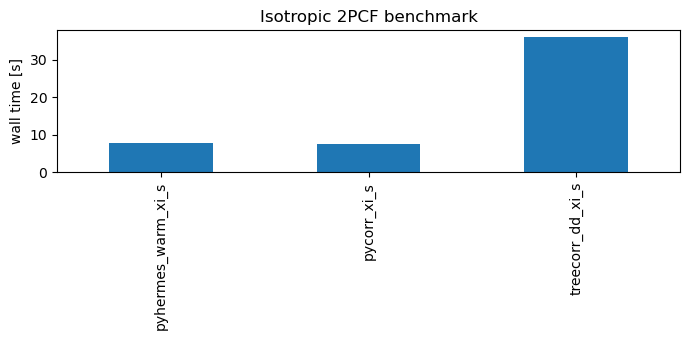

In [16]:
if not summary.empty:
    ok = summary[summary['status'].eq('ok')].copy()
    if len(ok):
        ax = ok.plot.bar(x='label', y='wall_time_s', legend=False, figsize=(7, 3.5))
        ax.set_ylabel('wall time [s]')
        ax.set_xlabel('')
        ax.set_title('Isotropic 2PCF benchmark')
        ax.figure.tight_layout()

## Curve comparison

The benchmark timings above compare runtime. The cells below also compare the measured isotropic 2PCF curves, plotted as $s^2\xi(s)$. pycorr and TreeCorr use identical finite radial bins, while PyHermes evaluates shell-window samples at the bin centers. For TreeCorr, the default notebook run stores DD only, so the comparison curve uses the periodic-box analytic RR normalization, `DD / RR - 1`.


saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/figs/benchmark_2pcf_isotropic_s2xi_curves.png
saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_s2xi_curves.npz


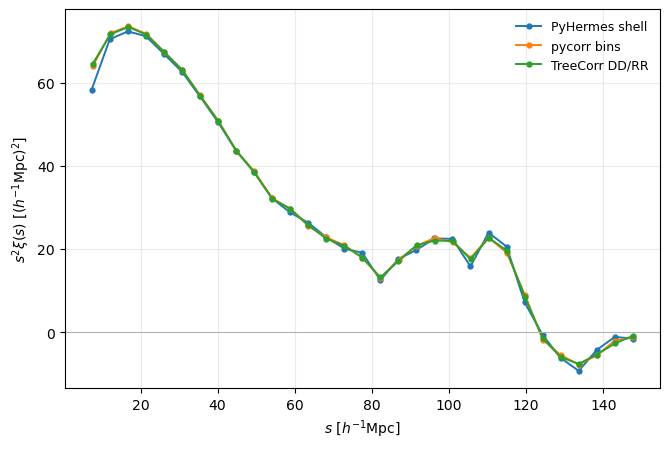

In [17]:
from pyhermes.io.corr2pcf import Corr2PCFData
import matplotlib.pyplot as plt


def pyhermes_curve():
    value = outputs.get('pyhermes_xi_s')
    if value is None and PYHERMES_OUTPUT_PATH.exists():
        value = Corr2PCFData(data_path=str(PYHERMES_OUTPUT_PATH), threads=1)
    if value is None or getattr(value, 'xi', None) is None:
        return None
    return np.asarray(value.s, dtype=float), np.asarray(value.xi, dtype=float)


def pycorr_curve():
    value = outputs.get('pycorr_xi_s')
    if value is None or getattr(value, 'corr', None) is None:
        return None
    sep = getattr(value, 'sep', None)
    if sep is None:
        sep = 0.5 * (S_EDGES[:-1] + S_EDGES[1:])
    return np.asarray(sep, dtype=float), np.asarray(value.corr, dtype=float)


def treecorr_curve():
    if outputs.get('treecorr_xi_with_rr') is not None:
        value = outputs['treecorr_xi_with_rr']
        dd = value['dd']
        sep = np.asarray(getattr(dd, 'meanr', None), dtype=float)
        if sep.size == 0 or not np.any(sep > 0):
            sep = np.asarray(dd.rnom, dtype=float)
        return sep, np.asarray(value['xi'], dtype=float)

    nn = outputs.get('treecorr_dd')
    if nn is None or getattr(nn, 'npairs', None) is None:
        return None

    left = np.asarray(nn.left_edges, dtype=float)
    right = np.asarray(nn.right_edges, dtype=float)
    sep = np.asarray(getattr(nn, 'meanr', None), dtype=float)
    if sep.size == 0 or not np.any(sep > 0):
        sep = np.asarray(nn.rnom, dtype=float)

    shell_volume = 4.0 * np.pi / 3.0 * (right**3 - left**3)
    rr_pairs = 0.5 * len(pos) * (len(pos) - 1) * shell_volume / BOX_SIZE**3
    xi = np.asarray(nn.npairs, dtype=float) / rr_pairs - 1.0
    return sep, xi


curves = {
    'PyHermes shell': pyhermes_curve(),
    'pycorr bins': pycorr_curve(),
    'TreeCorr DD/RR': treecorr_curve(),
}
curves = {name: curve for name, curve in curves.items() if curve is not None}

if len(curves) < 2:
    print('Need at least two successful benchmark outputs to compare curves.')
else:
    fig, ax = plt.subplots(figsize=(6.8, 4.6))

    for name, (x, y) in curves.items():
        y_scaled = y * x**2
        ax.plot(x, y_scaled, marker='o', markersize=3.5, linewidth=1.4, label=name)

    ax.axhline(0.0, color='0.7', linewidth=0.8)
    ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(r'$s^2\xi(s)\ [(h^{-1}\mathrm{Mpc})^2]$')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

    fig.tight_layout()
    FIGS_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = FIGS_DIR / 'benchmark_2pcf_isotropic_s2xi_curves.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')

    arrays_path = OUTPUT_DIR / 'benchmark_2pcf_isotropic_s2xi_curves.npz'
    np.savez(
        arrays_path,
        **{f'{name.replace(" ", "_").replace("/", "_")}_s': curve[0] for name, curve in curves.items()},
        **{f'{name.replace(" ", "_").replace("/", "_")}_xi': curve[1] for name, curve in curves.items()},
    )
    print('saved:', fig_path)
    print('saved:', arrays_path)
    plt.show()


## Interpretation notes

- For a single conventional isotropic 2PCF, compare PyHermes **warm** time with pycorr/TreeCorr pair-counting time if the PyHermes field has already been constructed for other measurements.
- Compare PyHermes **cold** time when the field projection is part of the task and cannot be reused.
- TreeCorr's DD-only timing is a pair-counting throughput measurement. If RR is enabled, report it as an explicit-random workflow.
- The PyHermes shell samples and pycorr/TreeCorr finite bins are not mathematically identical windows. For runtime reporting this is usually acceptable if the number of radial samples is matched, but result-level comparisons should use matched window definitions or be described carefully.